# Third Lesson: percussive sounds
Today we're going to look at percussive sounds. Let's first import the necessary libraries we already know.

In [161]:
from IPython.display import Audio
from random import random, seed
from math import exp, log

It's also useful to create a function that can play a wave we give as input, to avoid having to always write the same SR etc.:

In [162]:
def silence(duration, sample_rate=48000):
    return [0] * round(duration * sample_rate)

In [163]:
def play(wave):
    return Audio(wave, rate=48000,normalize=False, autoplay=True)

It's useful to create general variable for sample rate that we'll be able to modify throughout the whole lesson.  
The same is useful for the seed of the pseudo-random generator. PRG generate random values which actually aren't, they're based on a "seed", an index at which a really long number starts. To recreate exactly the way something works it might be useful, but if you want a truly random number generator different techniques are required.

In [13]:
SR=48000
seed(0)

## Hi-hat
### Closed hi-hat
**A closed hi-hat sound can be easily generated by random white noise decaying in time**.  
We can create a simple hi-hat as we saw in lesson 3 with the random function:
Not that the syntax
```
for _ in range()
```
just means "I don't care about the actual value, just do the same stuff the amount of times that is written in round()"

In [12]:
hihat = [random() for _ in range(round(0.1 * SR))]
play(hihat)

But this sound does not decay in amplitude, which would at least make the sound more similar to a real hi-hat. That would be possible with a decay, for instance a linear ramp that goes down to 0:

In [21]:
n = round(0.1 * SR)
hihat_2 = [random() * (1 - i/n) for i in range(n)]
play((hihat + silence(0.5) + hihat_2 + silence(0.5)) * 10)

We could improve it with an exponential! Let's look at it:

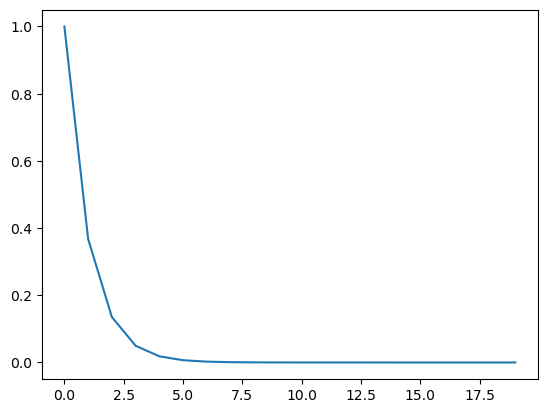

In [24]:
%matplotlib inline
from matplotlib import pyplot as plt
plt.plot([exp(-i) for i in range(20)])

Always remember that exponential decay $e^{-\alpha}$ becomes more vertical as $\alpha$ increases, or goes to zero more slowly if it's small.  
Note that a high decay_speed will make an inaudible sound, so we need a very small _decay_speed_.

In [28]:
decay_speed = 0.0005
d = 0.1
n = round(d*SR)
hihat_3 = [random() * exp(-i*decay_speed) for i in range(n)]
play(hihat_3)

Let's also plot it:

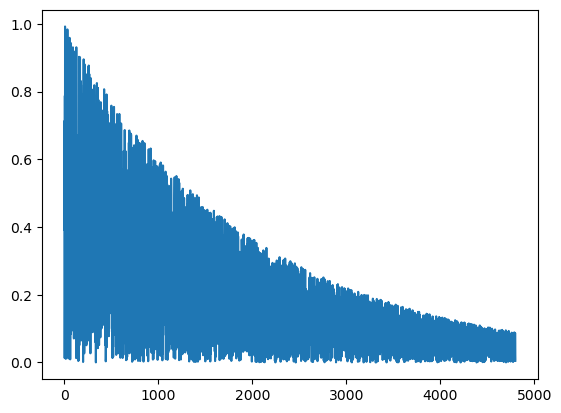

In [29]:
plt.plot(hihat_3)

Sometimes you might want to modulate a sound with many different shapes. How do we make it?  
We could create an envelope that we apply to noise (first with linear envelope, then with exponential):

In [30]:
noise = [random() for _ in range(n)]
envelope = [(1 - i/n) for i in range(n)]

In [31]:
hihat_4 = [noise[i] * envelope[i] for i in range(n)]
play(hihat_4)

In [32]:
exp_envelope = [exp(-i*decay_speed) for i in range(n)]
hihat_5 = [noise[i] * exp_envelope[i] for i in range(n)]

#### VCA
This is similar to **VCA (Voltage Control Amplifier)**: a signal is first amplified by a regular amplifier, and then modulated by a VCA. It's fundamental for synths.  
<u>oss</u> We must write range(len(wave)) because the envelope could be longer, but we just want it for the wave!

In [33]:
def vca(wave, envelope):
    return [wave[i] * envelope[i] for i in range(len(wave))]

In [34]:
play(vca(noise, envelope))

#### Using the zip method
We could do it more elegantly with the _zip_ function. The zip function creates an object that can be read as a list with the list function:

In [35]:
a = [1,2,3,4]
b = [6,7,8,9]
list(zip(a,b))

[(1, 6), (2, 7), (3, 8), (4, 9)]

_Note: structured list can be initialised like this:_

In [36]:
a, b = [1, 2]
print(a)
print(b)

1
2


With the zip function we can write the vca function like this:

In [37]:
def vca(wave, envelope):
    return [x * y for x, y in zip(wave, envelope)]

### Open hi-hat
**An open hi-hat sound is like a closed hi-hat just with longer decay.**  
First, let's create a function for noise and one for the exponential envelope just for simplicity, then let's see what we get with just a longer decay.  
If we keep playing around with it we might find something that sounds good!

In [126]:
def noise(duration, sample_rate=48000):
    n = round(duration * sample_rate)
    return [random() for _ in range(n)]

In [40]:
def exp_envelope(duration, decaying_speed, sample_rate=SR):
    n = round(duration*sample_rate)
    return [exp(-i*decaying_speed) for i in range(n)]

In [50]:
hihat_open = vca(noise(0.5), exp_envelope(0.5, decaying_speed=0.00025))
play(hihat_open)

## Kick
**A kick can be generated from a sine wave (or oscillatory wave) that rapidly drops in pitch.**  
Let's create a kick from a square wave which we'll import from the last lessons:

In [51]:
def square_wave(f = 440,
                sample_rate = 48000,
                amplitude = .15,
                duration = .5):

    period_duration = 1/f #in seconds
    period_samples = period_duration * sample_rate
    half_period_samples = period_samples/2
    number_of_periods = duration/period_duration
    
    return ([-amplitude] * round(half_period_samples) + 
            [amplitude] * round(half_period_samples)) * round(number_of_periods)

In [53]:
play(vca(square_wave(f=100,duration=0.1), exp_envelope(0.1, decaying_speed=0.00025)))

It still does not sound good. We can play with envelope and we must lower frequency, a lot.  
{He explained something, i did not follow}
We should rewrite the function. In this way, we can make the sound lower the frequency gradually.  
The modifications are:
- create a while loop that iterates different periods and adds them to a wave
- create n_samples so that I have a maximum samples to have for the sound
- create the wave empty list and the temporary variable useful for computations
- put minimum value for frequency to avoid infinite computation with max(f[i],20) when using exponential decay

In [85]:
def square_wave(f = [],
                sample_rate = 48000,
                amplitude = .15,
                duration = .5):

    n_samples = round(duration * sample_rate)# number of samples that my wave will have
    period_duration = 1/f[0]
    period_samples = period_duration * sample_rate
    half_period_samples = period_samples/2

    wave = []
    i = 0

    while i < n_samples:
        period_duration = 1/max(f[i],20) #in seconds
        period_samples = period_duration * sample_rate
        half_period_samples = period_samples/2
        
        wave += [-amplitude] * round(half_period_samples) + [amplitude] * round(half_period_samples)
        i = i + round(period_samples) # because this way it will give me the amount of samples we have in time
   
    return wave

In [86]:
play(square_wave([440 for _ in range(48000)]))

We can now add decay, let's first try with a linear ramp:

In [72]:
play(square_wave([440 * (1-i/48000) for i in range(48000)]))

We can get much closer with explonential decay. Note that we first generate the wave that lowers in pitch in variable _osc_, and then apply the exponential envelope. 

In [82]:
osc = square_wave([440 * exp(-i*0.002) for i in range(48000)], duration =.05)
play(vca(osc, exp_envelope(duration=0.1, decaying_speed=0.00025)))

## Snare
**A snare can be composed by a hit, obtained the same way as the kick that doesn't go to zero, and the membrane resonation can be approximated with white noise.**  
We can get an exponential decay that doesn't go to zero this way:

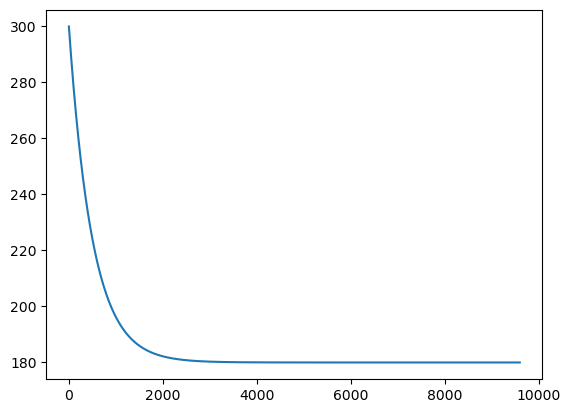

In [92]:
# starts from 300, doesn't go to 0!
plt.plot([180 + 120 * x for x in exp_envelope(duration=0.2,decaying_speed=0.002)])

By initializing a pitch that exponentially decays and with exponential envelope we can get the kick, and then

In [ ]:
# this is the vibrating part without the noise
pitch = [180 + 120 * x for x in exp_envelope(duration=0.2,decaying_speed=0.002)]
play(vca(exp_envelope(duration=0.2, decaying_speed=0.0005),square_wave(f=pitch, duration=0.2)))

In [113]:
# this is the noise part
DUR = 0.2
noise_snare = vca(exp_envelope(DUR, 0.0003), noise(duration=DUR))
play(noise_snare)

We can therefore create the snare with a membrane component (the one with the pitch) and we can sum it to the noise component to get a snare sound.

In [114]:
membrane = vca(exp_envelope(duration=0.2, decaying_speed=0.0005), square_wave(f=pitch,duration=0.2))

In [115]:
snare = [(x*0.2+y)*0.5 for x,y in zip(noise_snare, membrane)]
play(snare)

## Summary
We now have four sounds: two for the hi-hats, one for the kick and one for the snare. It would be useful to create some functions that allow us to create this sounds on the spot.  

In [116]:
def hihat_open(dur=.5, decaying_speed=0.00025):
    return vca(noise(dur), exp_envelope(dur, decaying_speed=decaying_speed))
play(hihat_open())

In [119]:
def hihat_closed(dur=.05, decaying_speed=0.000255):
    return vca(noise(dur), exp_envelope(duration=dur,decaying_speed=decaying_speed))

In [118]:
def kick():
    return square_wave([440 * exp(-i*0.002) for i in range(48000)], duration =.05)

In [137]:
def snare(duration=0.2, decaying_speed=0.0005):
    noise_var = vca(exp_envelope(DUR, 0.0003), noise(duration=duration))
    membrane = vca(exp_envelope(duration=duration,decaying_speed=decaying_speed), square_wave(f=pitch, duration=duration))
    return mix(noise_var,membrane,0.25,0.5)

In [138]:
play(snare())

It would also be useful to create a function to mix sounds: that way we can play multiple sounds at the same time!

In [136]:
def mix(wave1,wave2, g1=1, g2=1):
    return [g1 * x + g2 * y for x, y in zip(wave1, wave2)]

In [140]:
play(hihat_open() + hihat_closed() + silence(0.2) + kick() + silence(0.2) +snare())

## Taking timing into consideration
We want to create an "eigth" sound that lasts a specific duration

In [146]:
hihat = hihat_closed()
eight_duration = 0.3 #seconds
eight_samples = round(SR * eight_duration)
hihat_fit = hihat + [0] * (eight_samples - len(hihat))#fill the sample until it fills an eigth
hihats = hihat_fit * 8

play(hihats)

Great! Now let's try to create something like this for the kick if we want it just in specific positions:

In [148]:
kick_samples = kick()
eight_duration = 0.3 #seconds
eight_samples = round(SR * eight_duration)
kick_fit = kick_samples + [0] * (eight_samples - len(kick_samples))#fill the sample until it fills an eigth
kicks = (kick_fit + (3 * [0] * eigth_samples)) * 2

play(mix(hihats,kicks,0.1,0.5))

We create a function to make it fit.  
If the wave is longer than my slot I can truncate it with wave[:n_samples]

In [168]:
def fit(wave, n_samples):
    return wave[:n_samples] + [0] * (n_samples - len(wave[:n_samples]))


This way, the kick function becomes:

In [160]:
eight_duration = 0.3 #seconds
eight_samples = round(SR * eight_duration)
kicks = (fit(kick(), eight_samples) + (3 * fit([], eight_samples))) * 2
play(mix(kicks, hihats,0.5, 0.1))

## Homework:
Recreate the intro to "Weird Fishes/Arpeggios - Radiohead".  
This is my fast rendition on the intro; the sounds aren't good, and the volumes could be adjusted, but at least it works correctly!

In [174]:
# Let's avoid dynamics, for now

# bpm is 153, therefore sixteents last 0.098 seconds.
sixteenth_duration = 0.098
sixteenth_samples = round(SR * sixteenth_duration)


# create single sixteenth-silence
silence_16th = fit([], sixteenth_samples)
# it would also be useful to have an eigth silence
silence_8th = fit([], 2 * sixteenth_samples)
# hihats will be all eigths, to give it a small pause it would be a good idea to create an eight comprised by 16th note and 16th pause
hh_8th = fit(hihat_closed(), sixteenth_samples) + silence_16th
# since kicks only come in eights, let's make it last an eight
kick_8th = fit(kick(), 2 * sixteenth_samples)
# create single sixteenth-snare
snare_16th = fit(snare(), sixteenth_samples)

# First part is 32 sixteents. The second part is the same, but only one kick at the start. Let's write the components and then sum them:
hihats = hh_8th * 16
snares = (silence_8th * 2 + snare_16th + silence_8th + snare_16th) * 4
kick1 = kick_8th * 2 + silence_8th * 14
kick2 = kick_8th + silence_8th * 15

mixtemp = mix(hihats, snares, 0.5, 0.7)
drum_pattern = mix(mixtemp, kick1, 1, 1) + mix(mixtemp, kick2, 1, 1)
 
play(drum_pattern)